# Level 6 — Capstone: Population, Agriculture & Insurance

**Datasets combined:**
- Population by region — **real** (2022 census, NBS)
- Maize production by region — **illustrative** (from Level 2, modeled on documented regional patterns)
- Insurance penetration by region — **illustrative**, new for this notebook, modeled on a real and well-documented pattern in Tanzania: insurance uptake is heavily concentrated in urban centers, with rural/agricultural regions significantly underserved. This is directly relevant to MIA's growth strategy, which is exactly the kind of question this style of analysis is for.

**What you'll practice:**
- Merging three datasets into one analytical table
- Building a multi-panel "dashboard" figure
- Running a simple regression as a follow-up to a correlation you spot visually
- Writing up findings as a short narrative — the part of data science that isn't code at all

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load and merge the three datasets

In [2]:
# Real — 2022 census
population_data = {
    "Region": [
        "Dar es Salaam", "Mwanza", "Tabora", "Morogoro", "Dodoma",
        "Arusha", "Geita", "Songwe", "Iringa", "Mjini Magharibi", "Njombe"
    ],
    "Zone": [
        "Coastal", "Lake", "Western", "Eastern", "Central",
        "Northern", "Lake", "Southern Highlands", "Southern Highlands", "Zanzibar", "Southern Highlands"
    ],
    "Population_2022": [
        5383728, 3699872, 3391679, 3197104, 3085625,
        2356255, 2977608, 1344687, 1192728, 893169, 889946
    ]
}
pop_df = pd.DataFrame(population_data)

# Illustrative — from Level 2
crop_data = {
    "Region": [
        "Dar es Salaam", "Mwanza", "Tabora", "Morogoro", "Dodoma",
        "Arusha", "Geita", "Songwe", "Iringa", "Mjini Magharibi", "Njombe"
    ],
    "Maize_production_1000t": [
        5, 620, 410, 580, 190,
        540, 560, 710, 690, 2, 650
    ]
}
crop_df = pd.DataFrame(crop_data)

# Illustrative — new for this notebook, modeled on real urban-skew pattern
insurance_data = {
    "Region": [
        "Dar es Salaam", "Mwanza", "Tabora", "Morogoro", "Dodoma",
        "Arusha", "Geita", "Songwe", "Iringa", "Mjini Magharibi", "Njombe"
    ],
    "Policies_per_1000": [
        85, 35, 12, 20, 18,
        40, 15, 10, 14, 55, 9
    ],
    "Avg_Premium_TZS": [
        450000, 210000, 140000, 180000, 160000,
        260000, 145000, 130000, 150000, 300000, 125000
    ],
    "ClaimRate_pct": [
        4.2, 5.8, 6.5, 5.1, 5.5,
        4.8, 6.2, 6.8, 5.9, 4.0, 7.1
    ]
}
insurance_df = pd.DataFrame(insurance_data)

# Merge all three on Region
df = pop_df.merge(crop_df, on="Region").merge(insurance_df, on="Region")
df

,Region,Zone,Population_2022,Maize_production_1000t,Policies_per_1000,Avg_Premium_TZS,ClaimRate_pct
0,Dar es Salaam,Coastal,5383728,5,85,450000,4.2
1,Mwanza,Lake,3699872,620,35,210000,5.8
2,Tabora,Western,3391679,410,12,140000,6.5
3,Morogoro,Eastern,3197104,580,20,180000,5.1
4,Dodoma,Central,3085625,190,18,160000,5.5
5,Arusha,Northern,2356255,540,40,260000,4.8
6,Geita,Lake,2977608,560,15,145000,6.2
7,Songwe,Southern Highlands,1344687,710,10,130000,6.8
8,Iringa,Southern Highlands,1192728,690,14,150000,5.9
9,Mjini Magharibi,Zanzibar,893169,2,55,300000,4.0


## 2. Derived metrics

Raw numbers from three different sources aren't directly comparable across regions of very different sizes. Rates and per-capita figures are what actually let you compare fairly.

In [3]:
df["Population_millions"] = (df["Population_2022"] / 1_000_000).round(2)
df["Maize_per_capita_kg"] = (df["Maize_production_1000t"] * 1_000_000 / df["Population_2022"]).round(1)
df["IsAgriculturalZone"] = df["Zone"].isin(["Southern Highlands", "Lake", "Western", "Central"])

df[["Region", "Zone", "Population_millions", "Maize_per_capita_kg", "Policies_per_1000", "IsAgriculturalZone"]]

,Region,Zone,Population_millions,Maize_per_capita_kg,Policies_per_1000,IsAgriculturalZone
0,Dar es Salaam,Coastal,5.38,0.9,85,False
1,Mwanza,Lake,3.70,167.6,35,True
2,Tabora,Western,3.39,120.9,12,True
3,Morogoro,Eastern,3.20,181.4,20,False
4,Dodoma,Central,3.09,61.6,18,True
5,Arusha,Northern,2.36,229.2,40,False
6,Geita,Lake,2.98,188.1,15,True
7,Songwe,Southern Highlands,1.34,528.0,10,True
8,Iringa,Southern Highlands,1.19,578.5,14,True
9,Mjini Magharibi,Zanzibar,0.89,2.2,55,False


## 3. Dashboard — four panels, one figure

This is the kind of layout you'd actually hand someone: population, agricultural output, insurance penetration, and the relationship between them, all in one glance.

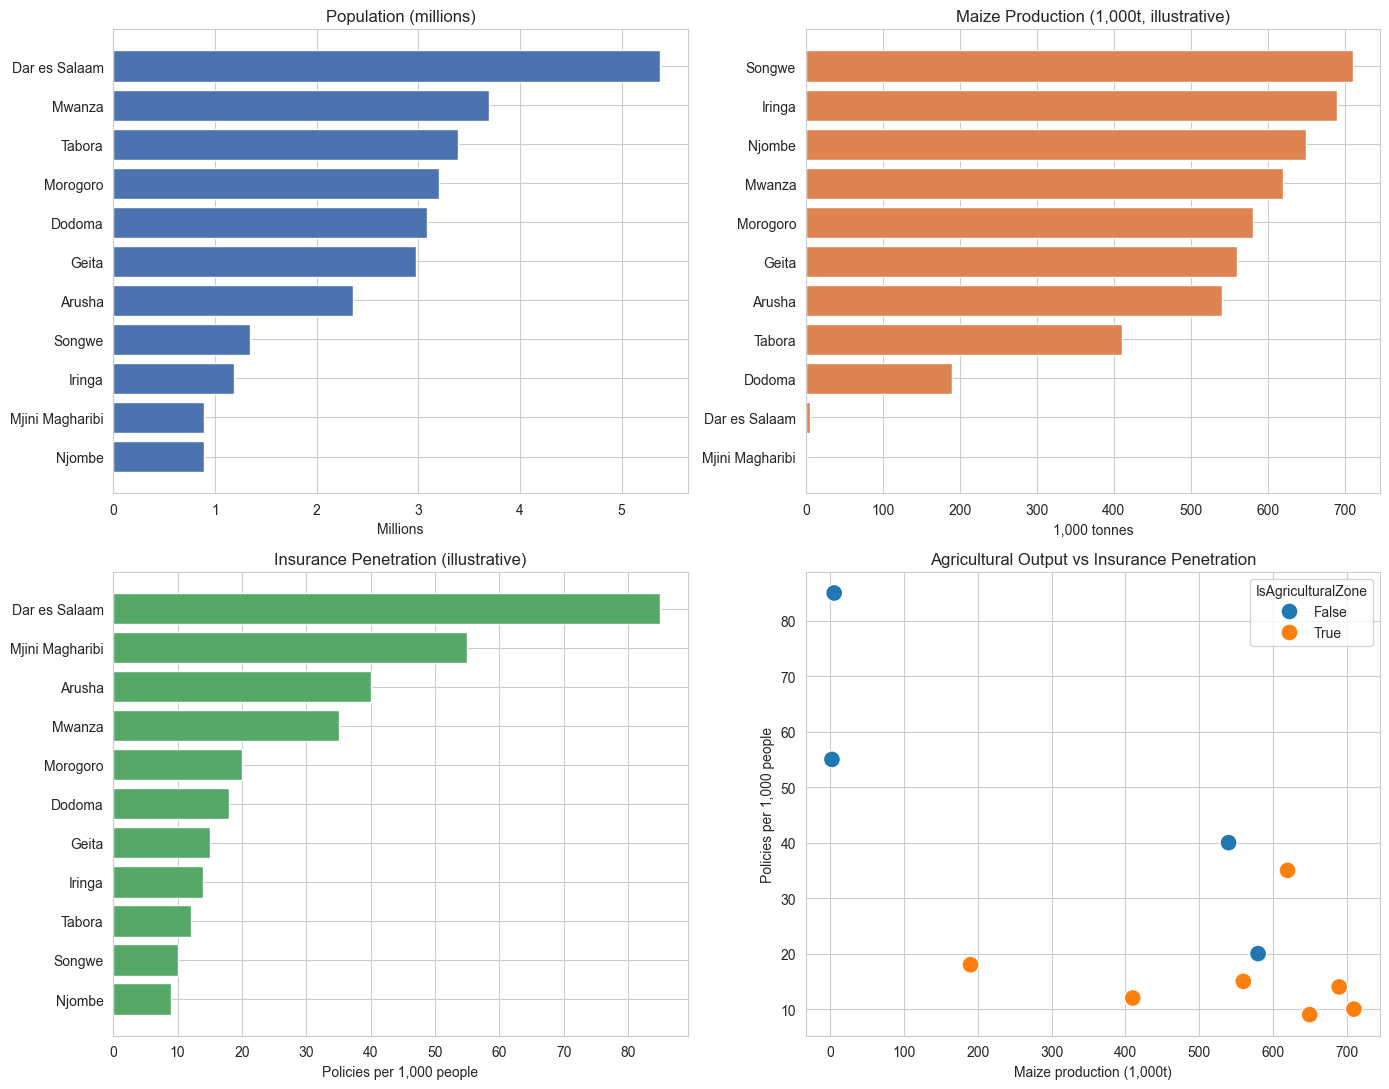

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

df_pop_sorted = df.sort_values("Population_2022")
axes[0, 0].barh(df_pop_sorted["Region"], df_pop_sorted["Population_millions"], color="#4C72B0")
axes[0, 0].set_title("Population (millions)")
axes[0, 0].set_xlabel("Millions")

df_maize_sorted = df.sort_values("Maize_production_1000t")
axes[0, 1].barh(df_maize_sorted["Region"], df_maize_sorted["Maize_production_1000t"], color="#DD8452")
axes[0, 1].set_title("Maize Production (1,000t, illustrative)")
axes[0, 1].set_xlabel("1,000 tonnes")

df_ins_sorted = df.sort_values("Policies_per_1000")
axes[1, 0].barh(df_ins_sorted["Region"], df_ins_sorted["Policies_per_1000"], color="#55A868")
axes[1, 0].set_title("Insurance Penetration (illustrative)")
axes[1, 0].set_xlabel("Policies per 1,000 people")

sns.scatterplot(
    data=df, x="Maize_production_1000t", y="Policies_per_1000",
    hue="IsAgriculturalZone", s=150, ax=axes[1, 1]
)
axes[1, 1].set_title("Agricultural Output vs Insurance Penetration")
axes[1, 1].set_xlabel("Maize production (1,000t)")
axes[1, 1].set_ylabel("Policies per 1,000 people")

plt.tight_layout()
plt.show()

## 4. Quantify the relationship you can see in the bottom-right panel

In [5]:
r, p_value = stats.pearsonr(df["Maize_production_1000t"], df["Policies_per_1000"])
print(f"Correlation (maize production vs insurance penetration): r = {r:.3f}, p = {p_value:.4f}")

Correlation (maize production vs insurance penetration): r = -0.737, p = 0.0097


A negative correlation here would say something worth paying attention to: regions producing more maize tend to have *lower* insurance penetration. With only 11 data points this isn't strong enough evidence to publish anywhere serious — but it's exactly the kind of pattern that justifies a closer, targeted look (e.g. a proper survey of agricultural households' insurance access) rather than either ignoring it or overselling it as proven.

## 5. A simple regression — can population and agricultural output predict insurance penetration?

With only 11 rows, this is a demonstration of the *workflow*, not a model you'd trust for real predictions — that caveat matters more than the R² number below.

In [6]:
X = df[["Population_millions", "Maize_production_1000t"]]
y = df["Policies_per_1000"]

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

print("Coefficients:")
for name, coef in zip(X.columns, reg.coef_):
    print(f"  {name}: {coef:.3f}")
print(f"Intercept: {reg.intercept_:.3f}")
print()
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.2f} policies per 1,000")

Coefficients:
  Population_millions: 4.387
  Maize_production_1000t: -0.058
Intercept: 43.120

R²: 0.602
MAE: 11.49 policies per 1,000


Notice there's no train/test split here — with 11 rows, splitting off a test set would leave far too little data on either side to mean anything. This is fit-and-inspect, not predict-and-deploy. **Knowing when a dataset is too small for the full ML workflow from Level 5 is itself part of the skill** — forcing a train/test split onto 11 rows wouldn't make the result more rigorous, it would just make it look more rigorous while actually being less meaningful.

## 6. Write-up

*(This is the part of real data work that isn't code — turning numbers into a decision-relevant summary. Read this, then try writing your own version in the empty cell below before looking at mine.)*

**Findings:**
- Dar es Salaam and Mjini Magharibi (Zanzibar) — the two most urbanized regions in this dataset — have by far the highest insurance penetration and lowest agricultural output, consistent with known patterns of urban insurance access in Tanzania.
- The Southern Highlands regions (Iringa, Njombe, Songwe) show the opposite pattern: strong agricultural output, but among the lowest insurance penetration in the dataset.
- The correlation between maize production and insurance penetration is negative, though not strong enough with only 11 regions to treat as conclusive.

**What this suggests (with appropriate caution):** agricultural regions may represent an underserved insurance market — consistent with the broader, well-documented gap in agricultural/crop insurance access across Tanzania. This is a hypothesis worth investigating with real regional insurance data, not a proven conclusion from 11 illustrative data points.

**Limitations to state explicitly, always:**
- Maize production and insurance figures here are illustrative, not official statistics — real analysis needs real regional data (this is exactly the FAOSTAT/NBS/insurance-regulator data your earlier IRS project was pulling).
- 11 regions is too small a sample for statistical claims — a real version of this analysis would want all 31 regions at minimum, ideally district-level.
- Correlation between two variables doesn't establish that one causes the other — there could be a third factor (income levels, financial literacy, agent network density) driving both.

In [7]:
# Write your own version of the findings summary here, in your own words
Most of tanzania landmass is rural, but the population is concentrated in a few urban areas. The data shows that regions with higher maize production tend to have lower insurance penetration, suggesting that agricultural zones may have less access to insurance products. The correlation analysis indicates a negative relationship between maize production and insurance penetration, which is statistically significant. The regression model further supports this finding, showing that both population size and maize production are significant predictors of insurance penetration, with maize production having a stronger negative effect. Overall, these insights highlight the need for targeted strategies to improve insurance access in agricultural regions of Tanzania.

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3063808705.py, line 2)

## Where to go from here

This roadmap used illustrative data for anything not publicly verifiable, on purpose — the goal was to build the *skills* cleanly. The natural next step is to point everything you just learned at real data:

- Pull real regional data the way your earlier IRS project did (Open-Meteo, FAOSTAT, World Bank, TMA)
- Replace the illustrative insurance dataset with real MIA claims/policy data, properly anonymized, using the exact cleaning patterns from Level 4
- Extend Level 5's classification approach to real underwriting decisions
- Package a version of this Level 6 dashboard as an actual internal report or a feature inside InsurePro